# KNMI Raw .txt to CSV Converter

Converts raw KNMI hourly download files (`.txt` with `#` comment headers) into a clean `.csv` for downstream use in graph generation and data validation.

**Input:** Direct download `.txt` from [KNMI Uurgegevens](https://www.knmi.nl/nederland-nu/klimatologie/uurgegevens)  
**Output:** Clean CSV with proper timestamps and converted units in `input_stressors/`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from io import StringIO

# Find repo root
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break

print('Repo root:', repo_root)

Repo root: d:\Users\jvanruitenbeek\data_validation


## Configuration

Set the input filename and station info here. Point `input_filename` to any raw KNMI hourly `.txt` download.

In [2]:
input_filename = 'knmi_249_berkhout_24_juni.txt'
output_filename = 'knmi_249_berkhout_hourly.csv'

input_path = repo_root / 'input_stressors' / input_filename
output_path = repo_root / 'input_stressors' / output_filename

print(f'Input:  {input_path}')
print(f'Output: {output_path}')
print(f'File exists: {input_path.exists()}')

Input:  d:\Users\jvanruitenbeek\data_validation\input_stressors\knmi_249_berkhout_24_juni.txt
Output: d:\Users\jvanruitenbeek\data_validation\input_stressors\knmi_249_berkhout_hourly.csv
File exists: True


## 1. Parse raw KNMI file

The raw KNMI `.txt` file has:
- Comment lines starting with `#` (metadata + variable descriptions)
- The last `#` line contains the column header
- Data lines are comma-separated with leading/trailing whitespace

In [3]:
with open(input_path, 'r') as f:
    lines = f.readlines()

header_line = None
data_start = None
for i, line in enumerate(lines):
    if line.startswith('#'):
        header_line = line
        data_start = i + 1

columns = [c.strip() for c in header_line.lstrip('#').strip().split(',')]
data_text = ''.join(lines[data_start:])

df = pd.read_csv(StringIO(data_text), header=None, names=columns)
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
print(f'Columns: {columns}')
print(f'Date range: {df["YYYYMMDD"].iloc[0]} – {df["YYYYMMDD"].iloc[-1]}')
df.head()

C:\Users\jvanruitenbeek\AppData\Local\Temp\70\ipykernel_15540\2856673672.py:14: DtypeWarning: Columns (3,4,5,6,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(data_text), header=None, names=columns)


Loaded 56760 rows, 25 columns
Columns: ['STN', 'YYYYMMDD', 'HH', 'DD', 'FH', 'FF', 'FX', 'T', 'T10N', 'TD', 'SQ', 'Q', 'DR', 'RH', 'P', 'VV', 'N', 'U', 'WW', 'IX', 'M', 'R', 'S', 'O', 'Y']
Date range: 20200101 – 20260622


,STN,YYYYMMDD,HH,DD,FH,FF,FX,T,T10N,TD,...,VV,N,U,WW,IX,M,R,S,O,Y
0,249,20200101,1,160,30,20,50,29,,26,...,20,,98,20,7,1,0,0,0,0
1,249,20200101,2,150,20,20,40,27,,26,...,5,,99,34,7,1,0,0,0,0
2,249,20200101,3,140,30,40,60,28,,25,...,12,,97,20,7,1,0,0,0,0
3,249,20200101,4,170,40,40,70,18,,17,...,2,,99,34,7,1,0,0,0,0
4,249,20200101,5,170,40,30,60,19,,18,...,4,,99,32,7,1,0,0,0,0


## 2. Create timestamp index

KNMI uses `HH=1..24` where `HH=24` means midnight of the next day (i.e. 00:00 the following day). We convert this to a proper `DatetimeIndex`.

In [4]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['date'] = pd.to_datetime(df['YYYYMMDD'].astype(int).astype(str), format='%Y%m%d')
df['HH'] = df['HH'].astype(int)
df['timestamp'] = df['date'] + pd.to_timedelta(df['HH'], unit='h')
df = df.set_index('timestamp').sort_index()
df = df.drop(columns=['date'])

print(f'Timestamp range: {df.index.min()} – {df.index.max()}')
print(f'Total rows: {len(df)}')
df.head()

Timestamp range: 2020-01-01 01:00:00 – 2026-06-23 00:00:00
Total rows: 56760


,STN,YYYYMMDD,HH,DD,FH,FF,FX,T,T10N,TD,...,VV,N,U,WW,IX,M,R,S,O,Y
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,249,20200101,1,160.0,30.0,20.0,50.0,29,NaN,26,...,20.0,NaN,98,20.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00,249,20200101,2,150.0,20.0,20.0,40.0,27,NaN,26,...,5.0,NaN,99,34.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00,249,20200101,3,140.0,30.0,40.0,60.0,28,NaN,25,...,12.0,NaN,97,20.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00,249,20200101,4,170.0,40.0,40.0,70.0,18,NaN,17,...,2.0,NaN,99,34.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 05:00:00,249,20200101,5,170.0,40.0,30.0,60.0,19,NaN,18,...,4.0,NaN,99,32.0,7.0,1.0,0.0,0.0,0.0,0.0


## 3. Convert KNMI units to physical units

| Column | KNMI unit | Converted unit |
|--------|-----------|----------------|
| DD | degrees | degrees (no change) |
| FH, FF, FX | 0.1 m/s | m/s |
| T, T10N, TD | 0.1 °C | °C |
| SQ | 0.1 hour | hours |
| Q | J/cm² | J/cm² (no change) |
| DR | 0.1 hour | hours |
| RH | 0.1 mm (-1 = <0.05mm) | mm |
| P | 0.1 hPa | hPa |
| U | % | % (no change) |

In [5]:
converted = df.copy()

for col in ['FH', 'FF', 'FX']:
    converted[col] = converted[col] / 10.0

for col in ['T', 'T10N', 'TD']:
    converted[col] = converted[col] / 10.0

for col in ['SQ', 'DR']:
    converted[col] = converted[col] / 10.0

converted['RH'] = converted['RH'].where(converted['RH'] >= 0, 0) / 10.0

converted['P'] = converted['P'] / 10.0

rename_map = {
    'STN': 'station',
    'YYYYMMDD': 'date_int',
    'HH': 'hour',
    'DD': 'wind_direction_deg',
    'FH': 'wind_speed_hourly_ms',
    'FF': 'wind_speed_10min_ms',
    'FX': 'wind_gust_max_ms',
    'T': 'temperature_C',
    'T10N': 'temperature_10cm_min_C',
    'TD': 'dewpoint_C',
    'SQ': 'sunshine_duration_h',
    'Q': 'global_radiation_Jcm2',
    'DR': 'precipitation_duration_h',
    'RH': 'precipitation_mm',
    'P': 'pressure_hPa',
    'VV': 'visibility_code',
    'N': 'cloud_cover_octants',
    'U': 'relative_humidity_pct',
    'WW': 'weather_code',
    'IX': 'weather_code_indicator',
    'M': 'fog',
    'R': 'rain',
    'S': 'snow',
    'O': 'thunder',
    'Y': 'ice_formation',
}
converted = converted.rename(columns=rename_map)

print(f'Converted dataframe: {converted.shape}')
converted.head()

Converted dataframe: (56760, 25)


,station,date_int,hour,wind_direction_deg,wind_speed_hourly_ms,wind_speed_10min_ms,wind_gust_max_ms,temperature_C,temperature_10cm_min_C,dewpoint_C,...,visibility_code,cloud_cover_octants,relative_humidity_pct,weather_code,weather_code_indicator,fog,rain,snow,thunder,ice_formation
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 01:00:00,249,20200101,1,160.0,3.0,2.0,5.0,2.9,NaN,2.6,...,20.0,NaN,98,20.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00,249,20200101,2,150.0,2.0,2.0,4.0,2.7,NaN,2.6,...,5.0,NaN,99,34.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00,249,20200101,3,140.0,3.0,4.0,6.0,2.8,NaN,2.5,...,12.0,NaN,97,20.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00,249,20200101,4,170.0,4.0,4.0,7.0,1.8,NaN,1.7,...,2.0,NaN,99,34.0,7.0,1.0,0.0,0.0,0.0,0.0
2020-01-01 05:00:00,249,20200101,5,170.0,4.0,3.0,6.0,1.9,NaN,1.8,...,4.0,NaN,99,32.0,7.0,1.0,0.0,0.0,0.0,0.0


## 4. Quick sanity check

In [6]:
print('=== Sanity check ===')
print(f'\nDate range: {converted.index.min()} – {converted.index.max()}')
print(f'Total hours: {len(converted)}')

expected_hours = (converted.index.max() - converted.index.min()).total_seconds() / 3600
print(f'Expected hours (continuous): {int(expected_hours)}')
print(f'Missing hours: {int(expected_hours) - len(converted) + 1}')

print(f'\nTemperature (°C): {converted["temperature_C"].min():.1f} – {converted["temperature_C"].max():.1f}')
print(f'Precipitation total (mm): {converted["precipitation_mm"].sum():.1f}')
print(f'Pressure (hPa): {converted["pressure_hPa"].min():.1f} – {converted["pressure_hPa"].max():.1f}')

print(f'\nYearly precipitation (mm):')
print(converted['precipitation_mm'].resample('YE').sum())

=== Sanity check ===

Date range: 2020-01-01 01:00:00 – 2026-06-23 00:00:00
Total hours: 56760
Expected hours (continuous): 56759
Missing hours: 0

Temperature (°C): -9.7 – 33.7
Precipitation total (mm): 5743.6
Pressure (hPa): nan – nan

Yearly precipitation (mm):
timestamp
2020-12-31     938.5
2021-12-31     851.6
2022-12-31     737.0
2023-12-31    1127.7
2024-12-31    1050.4
2025-12-31     737.8
2026-12-31     300.6
Freq: YE-DEC, Name: precipitation_mm, dtype: float64


## 5. Makkink evaporation (mm/hour)

Compute hourly Makkink ET from temperature and global radiation, then show yearly and cumulative totals alongside precipitation.

In [7]:
T_C = converted['temperature_C']
Rs_MJ = converted['global_radiation_Jcm2'].clip(lower=0) * 0.01  # J/cm2 -> MJ/m2

gamma = 0.066       # kPa/°C
lambda_MJ = 2.45    # MJ/m2 per mm

delta = (
    4098
    * (0.6108 * np.exp((17.27 * T_C) / (T_C + 237.3)))
    / ((T_C + 237.3) ** 2)
)

converted['makkink_mm'] = (
    0.65
    * (delta / (delta + gamma))
    * (Rs_MJ / lambda_MJ)
).clip(lower=0)

print('Yearly Makkink evaporation (mm):')
print(converted['makkink_mm'].resample('YE').sum())
print(f'\nMean per year: {converted["makkink_mm"].resample("YE").sum().mean():.1f} mm')

Yearly Makkink evaporation (mm):
timestamp
2020-12-31    694.619492
2021-12-31    639.369025
2022-12-31    740.806139
2023-12-31    685.106234
2024-12-31    663.390385
2025-12-31    733.395558
2026-12-31    349.376708
Freq: YE-DEC, Name: makkink_mm, dtype: float64

Mean per year: 643.7 mm


## 6. Yearly and cumulative precipitation & evaporation

In [8]:
yearly_prec = converted['precipitation_mm'].resample('YE').sum()
yearly_evap = converted['makkink_mm'].resample('YE').sum()

yearly = pd.DataFrame({
    'Precipitation (mm)': yearly_prec,
    'Makkink ET (mm)': yearly_evap,
    'P - ET (mm)': yearly_prec - yearly_evap,
})
print('=== Yearly totals ===')
print(yearly.to_string())
print(f'\nTotal precipitation: {converted["precipitation_mm"].sum():.1f} mm')
print(f'Total Makkink ET:    {converted["makkink_mm"].sum():.1f} mm')

=== Yearly totals ===
            Precipitation (mm)  Makkink ET (mm)  P - ET (mm)
timestamp                                                   
2020-12-31               938.5       694.619492   243.880508
2021-12-31               851.6       639.369025   212.230975
2022-12-31               737.0       740.806139    -3.806139
2023-12-31              1127.7       685.106234   442.593766
2024-12-31              1050.4       663.390385   387.009615
2025-12-31               737.8       733.395558     4.404442
2026-12-31               300.6       349.376708   -48.776708

Total precipitation: 5743.6 mm
Total Makkink ET:    4506.1 mm


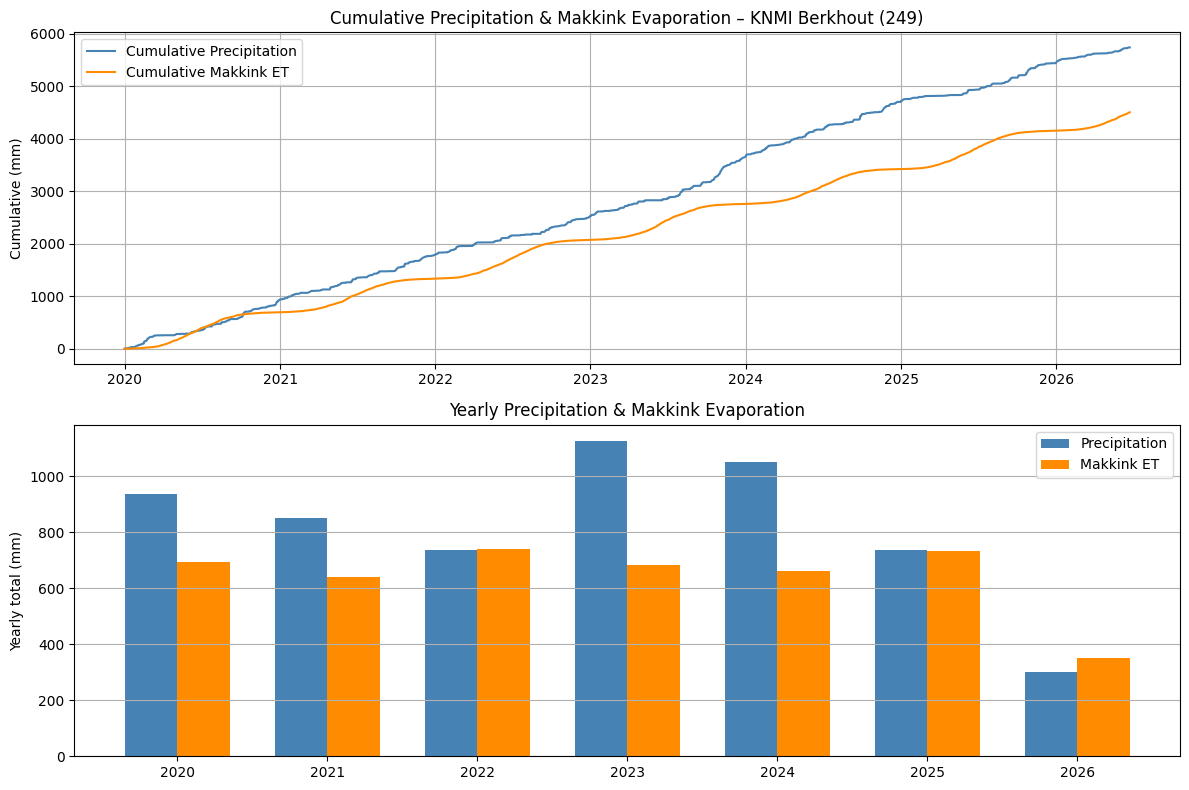

In [9]:
import matplotlib.pyplot as plt

daily_prec = converted['precipitation_mm'].resample('D').sum()
daily_evap = converted['makkink_mm'].resample('D').sum()

cum_prec = daily_prec.cumsum()
cum_evap = daily_evap.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Cumulative plot
axes[0].plot(cum_prec.index, cum_prec.values, label='Cumulative Precipitation', color='steelblue')
axes[0].plot(cum_evap.index, cum_evap.values, label='Cumulative Makkink ET', color='darkorange')
axes[0].set_ylabel('Cumulative (mm)')
axes[0].set_title('Cumulative Precipitation & Makkink Evaporation – KNMI Berkhout (249)')
axes[0].legend()
axes[0].grid(True)

# Yearly bar plot
years = yearly.index.year
x = np.arange(len(years))
width = 0.35
axes[1].bar(x - width/2, yearly['Precipitation (mm)'], width, label='Precipitation', color='steelblue')
axes[1].bar(x + width/2, yearly['Makkink ET (mm)'], width, label='Makkink ET', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(years)
axes[1].set_ylabel('Yearly total (mm)')
axes[1].set_title('Yearly Precipitation & Makkink Evaporation')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

## 7. Save to CSV

In [10]:
converted.to_csv(output_path, index=True)

print(f'Saved to: {output_path}')
print(f'File size: {output_path.stat().st_size / 1024:.0f} KB')

Saved to: d:\Users\jvanruitenbeek\data_validation\input_stressors\knmi_249_berkhout_hourly.csv
File size: 7017 KB
